In [14]:
# copy and paste the lines needed to read in the large galaxy zoo catalog from the first observed galaxies notebook
import pandas as pd

gz_data = pd.read_csv('../Data/galaxyzoo_research.csv')

In [27]:
gz_data

,OBJID,RA,DEC,REDSHIFT,P_ELLIPTICAL,P_SPIRAL,UMAG,GMAG,RMAG,IMAG,ZMAG,LOG_MASS,R90_ARCSEC,AXIAL_RATIO,LOCAL_DENSITY,NEARCLUSTER_DIST,NEARCLUSTER_MASS
0,5.880180e+17,218.580808,8.161055,0.053766,0.530869,0.437261,-18.684864,-20.204231,-20.955414,-21.298212,-21.558670,10.516412,6.294165,0.368354,-0.1800,-999.000000,-9.990000e+02
1,5.877300e+17,239.931122,3.644782,0.054367,0.000000,0.961538,-20.101736,-21.384073,-21.838770,-21.980230,-22.158155,10.592430,14.513707,0.799851,-0.2080,15.959925,5.430000e+12
2,5.877242e+17,10.641342,15.445178,0.079503,0.470876,0.491672,-19.834967,-21.217686,-21.850147,-22.147160,-22.348995,10.828524,7.862754,0.879052,0.8070,1.059320,3.940000e+14
3,5.877415e+17,165.379954,28.187846,0.069913,0.532013,0.424623,-19.435511,-20.811283,-21.509943,-21.847149,-22.106108,10.672685,6.840029,0.930676,0.0285,-999.000000,-9.990000e+02
4,5.877300e+17,216.307612,-1.099459,0.055574,0.647059,0.088235,-18.376757,-19.623747,-20.199842,-20.470566,-20.681120,9.964785,3.187091,0.831526,0.1040,11.604042,3.740000e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5.877334e+17,231.967240,50.455685,0.073404,0.946228,0.019281,-19.803755,-21.573761,-22.339725,-22.708660,-22.984587,11.098833,8.970359,0.721744,-0.5390,12.696922,1.450000e+14
19996,5.880177e+17,243.777330,6.092806,0.059610,0.758621,0.000000,-16.315529,-20.404915,-21.282505,-21.124458,-22.213829,11.365675,13.147679,0.741964,-0.5400,-999.000000,-9.990000e+02
19997,5.877250e+17,184.644965,-1.598657,0.079722,0.129100,0.562271,-19.415325,-20.450088,-20.837673,-20.960474,-21.146212,10.002666,5.776074,0.621813,-0.6670,19.389032,6.630000e+14
19998,5.877258e+17,118.714675,45.705057,0.052579,0.837452,0.064308,-19.477306,-21.262995,-22.042334,-22.473787,-22.752541,10.986648,11.711008,0.841293,1.4600,0.000000,8.510000e+13


**Copy and paste your table for the descriptions of the columns**



## Galaxy Zoo Types

We only tested a couple of tens of galaxies, but there are billions in the Universe! We can expand our sample by using the full galaxy zoo data that we read in earlier. It still only has a small subsample of galaxies, but 20,000 is much bigger than 20!

Just like before, let's say a galaxy is elliptical if it is classified as elliptical 80% of the time, and that it is a sprial if it is classified as spiral 80% of the time. This means we want the probability to be equal to or greater than 0.8. Pull out the relevant probabilities from the big Galaxy Zoo catalog. Make sure you aren't repeating variable names!

In [17]:
# grabbing the Galaxy Zoo probability columns
gz_prob_elliptical = gz_data['P_ELLIPTICAL']
gz_prob_spiral = gz_data['P_SPIRAL']

In [30]:
# make Boolean arrays based on the probabilites above
gz_elliptical_bool = gz_prob_elliptical >= 0.8
gz_spiral_bool = gz_prob_spiral >= 0.8

gz_elliptical_bool

0        False
1        False
2        False
3        False
4        False
         ...  
19995     True
19996    False
19997    False
19998     True
19999     True
Name: P_ELLIPTICAL, Length: 20000, dtype: bool

In [31]:
gz_spiral_bool

0        False
1         True
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Name: P_SPIRAL, Length: 20000, dtype: bool

In [26]:
# the sum of the Boolean arrays tell us how many galaxies passed each test

print('The number of elliptical galaxies is', sum(gz_elliptical_bool)) # fill in the sum after the comma
print('The number of spiral galaxies is', sum(gz_spiral_bool)) # fill in the sum after the comma
print('The total number of galaxies classifed is', len(gz_prob_elliptical))

The number of elliptical galaxies is 2509
The number of spiral galaxies is 6881
The total number of galaxies classifed is 20000


**How do the results of your data and the full Galaxy Zoo data compare? (Go back to Observed Galaxies Pt2 to see your results)**

**Answer:** The result outcome that I got are the same, the number of spiral galaxies are more than the elliptical galaxies.

It is not super fair for us to compare the number of elliptical/spirals in each data group because the sizes are very different. Let's calculate the percent of each type of galaxy in the two data groups. Remember, we can calculate the percent of something by doing: $\rm \frac{number\ of\ specific}{total} \times 100$

Calcualte and compare the 4 percents below.

In [20]:
# first we need to bring in the data you created in the last notebook. copy and paste the lines of code to read in that data

data_class = pd.read_csv('../Data/galazyzoo_experiment.csv')
data_class

,Galaxy ID,Total # of classifications,Elliptical,Spiral,Merger,Artifact,SSDS ID,Image,GZ Original Elliptical,GZ Original Spiral,GZ Original Merger,GZ Original Artifact,Computer Classification
0,1,10,0,10,0,0,1237648720142336185,http://skyserver.sdss.org/dr8/en/tools/explore...,0,37,0,0,Not Elliptical
1,2,10,6,3,1,0,1237648721215815838,http://skyserver.sdss.org/dr8/en/tools/explore...,3,53,1,0,Not Elliptical
2,3,10,2,8,0,0,1237648721215946942,http://skyserver.sdss.org/dr8/en/tools/explore...,5,58,0,0,Not Elliptical
3,4,10,8,0,1,1,1237648721216078045,http://skyserver.sdss.org/dr8/en/tools/explore...,35,0,0,0,Elliptical
4,5,10,5,4,0,1,1237648721216078463,http://skyserver.sdss.org/dr8/en/tools/explore...,0,31,0,1,Not Elliptical
5,6,10,0,1,9,0,1237648721245503521,http://skyserver.sdss.org/dr8/en/tools/explore...,1,0,25,1,Elliptical
6,7,10,0,10,0,0,1237648722295914556,http://skyserver.sdss.org/dr8/en/tools/explore...,0,23,0,0,Not Elliptical
7,8,10,7,0,0,3,1237650795146576091,http://skyserver.sdss.org/dr8/en/tools/explore...,38,1,0,3,Unable to Determine
8,9,10,8,0,0,2,1237650795683381426,http://skyserver.sdss.org/dr8/en/tools/explore...,63,2,0,0,Unable to Determine
9,10,10,0,10,0,0,1237650796219596962,http://skyserver.sdss.org/dr8/en/tools/explore...,0,26,0,0,Not Elliptical


In [32]:
# copy and paste ALL lines of code after you printed the data table. (You can ignore the print statements at the end.)

# pull out the columns that are relevant
elliptical = data_class['Elliptical']
spiral = data_class['Spiral']
tot_number = data_class['Total # of classifications']

# fill in the following code to calculate the probability of a galaxy being a spiral or an elliptical 
prob_elliptical = elliptical / tot_number
prob_spiral = spiral / tot_number

# set up the Boolean arrays for elliptical and spiral galaxies
elliptical_bool = prob_elliptical >= 0.8
spiral_bool = prob_spiral >= 0.8

print(elliptical_bool)

0     False
1     False
2     False
3      True
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16     True
17    False
18    False
19    False
20    False
21    False
dtype: bool


In [33]:
spiral_bool

0      True
1     False
2      True
3     False
4     False
5     False
6      True
7     False
8     False
9      True
10    False
11     True
12    False
13     True
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
dtype: bool

In [37]:
# now calculate the percents

# my data
ellip_percent = sum(elliptical_bool) / len(tot_number) * 100
spiral_percent = sum(spiral_bool) / len(tot_number) * 100

ellip_percent

13.636363636363635

In [38]:
spiral_percent

27.27272727272727

In [40]:
# galaxy zoo
gz_ellip_percent = sum(gz_elliptical_bool) / len(gz_prob_elliptical) * 100
gz_spiral_percent = sum(gz_spiral_bool) / len(gz_prob_spiral) * 100

gz_ellip_percent

12.545

In [41]:
gz_spiral_percent

34.405

In [42]:

# print the results -- fill in the name of the appropriate variable in between the commas in the print statments
print('For my data:')
print('The percentage of elliptical galaxies is',13.6 , '%')
print('The percentage of spiral galaxies is',27.3 , '%')
print('')
print('For all of the Galaxy Zoo data:')
print('The percentage of elliptical galaxies is',12.5 , '%')
print('The percentage of spiral galaxies is',34.4 , '%')

For my data:
The percentage of elliptical galaxies is 13.6 %
The percentage of spiral galaxies is 27.3 %

For all of the Galaxy Zoo data:
The percentage of elliptical galaxies is 12.5 %
The percentage of spiral galaxies is 34.4 %


**How do the percentages between the two data sets compare?**

**Answer:** The percentages are slightly similar for the my data and the galaxy zoo data, and the pecentage for spiral galaxies for both data are more than the elliptical galaxies.

## Galaxy Evolution

Like stars, galaxies form when super massive clouds of gas collapse because of gravity. These super massive clouds form stars overtime, and that creates a galaxy. 

Galaxies grow overtime through merging with other galaxies. Similarly to a business merger, this involves at least two galaxies coming together to form a bigger galaxy. Here is a video (https://www.youtube.com/watch?v=SZfOyyGMSGg&ab_channel=VideoFromSpace) showing images of galaxies in the process of merging. Note how they don't have a clear spiral or elliptical shape. This video (https://www.youtube.com/watch?v=lXy3B2K47Qg&ab_channel=VideoFromSpaceVideoFromSpaceVerified) shows computer images matched with real images of galaxies in the process of merging. The merging process takes billions of years, so we cannot watch it happen, which is why we need computers to know what the process looks like. The fact that images from the computer matches real images we see from space gives us confidence that the computer images are accurate!

(I like to think about this as "galactic cannibalism" and that galaxies grow by eating other galaxies.) Galaxies do this A LOT. Our own Milky Way has eaten many small galaxies over time. Below are computer images showing how this could work. 

<br>
<center>
<div>
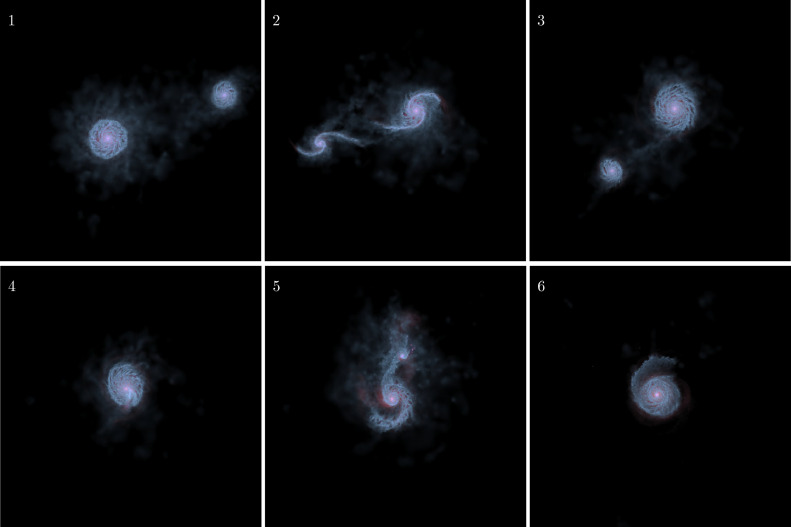
<div>
<center>    
    
<center>
Computer images of a galaxy and a smaller galaxy merger across panels 1-6. Note how the final galaxy doesn't look too different from the initial bigger galaxy. The more massive one "wins," and the smaller one is destroyed and eaten by the bigger one.
<center>
    
    
    
<br>
    
    
When two galaxies that have similar masses merge, they form a totally new galaxy that doesn't always look like one of the originals. This is especially true when two spiral galaxies of the same mass merge. They lose their spiral arms and get puffed out, resulting in a galaxy that looks like an ...elliptical galaxy! In fact, this is how we think elliptical galaxies are formed! Check out this vide of two spiral galaxies merge: https://www.youtube.com/watch?v=QcDtJ_-jdMw&ab_channel=HubbleSpaceTelescope
    
Here is a video (https://www.youtube.com/watch?v=4disyKG7XtU&ab_channel=VideoFromSpace) showing a computer-made video of what will happen in billions of years when the Milky Way and its large neighbor the Andromeda Galaxy collide. 

**What are some observations you notice from the two above videos?**

**Observations:** it takes billions of years for galaxies to collide. In the process of colliding, the shape of the galaxy will be ruined but eventually in many billions of years later it's going to form a shape.

## Deliverable: Ellipticals vs Spirals Ages

Let's think about the ages of spiral galaxies and elliptical galaxies. It is hard to know the age of a galaxy, so we can focus on general trends.

**Based on the information above, which type of galaxy do you think tend to be older?**

**Your hypothesis:** Spiral galaxies

In [43]:
gz_data

,OBJID,RA,DEC,REDSHIFT,P_ELLIPTICAL,P_SPIRAL,UMAG,GMAG,RMAG,IMAG,ZMAG,LOG_MASS,R90_ARCSEC,AXIAL_RATIO,LOCAL_DENSITY,NEARCLUSTER_DIST,NEARCLUSTER_MASS
0,5.880180e+17,218.580808,8.161055,0.053766,0.530869,0.437261,-18.684864,-20.204231,-20.955414,-21.298212,-21.558670,10.516412,6.294165,0.368354,-0.1800,-999.000000,-9.990000e+02
1,5.877300e+17,239.931122,3.644782,0.054367,0.000000,0.961538,-20.101736,-21.384073,-21.838770,-21.980230,-22.158155,10.592430,14.513707,0.799851,-0.2080,15.959925,5.430000e+12
2,5.877242e+17,10.641342,15.445178,0.079503,0.470876,0.491672,-19.834967,-21.217686,-21.850147,-22.147160,-22.348995,10.828524,7.862754,0.879052,0.8070,1.059320,3.940000e+14
3,5.877415e+17,165.379954,28.187846,0.069913,0.532013,0.424623,-19.435511,-20.811283,-21.509943,-21.847149,-22.106108,10.672685,6.840029,0.930676,0.0285,-999.000000,-9.990000e+02
4,5.877300e+17,216.307612,-1.099459,0.055574,0.647059,0.088235,-18.376757,-19.623747,-20.199842,-20.470566,-20.681120,9.964785,3.187091,0.831526,0.1040,11.604042,3.740000e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5.877334e+17,231.967240,50.455685,0.073404,0.946228,0.019281,-19.803755,-21.573761,-22.339725,-22.708660,-22.984587,11.098833,8.970359,0.721744,-0.5390,12.696922,1.450000e+14
19996,5.880177e+17,243.777330,6.092806,0.059610,0.758621,0.000000,-16.315529,-20.404915,-21.282505,-21.124458,-22.213829,11.365675,13.147679,0.741964,-0.5400,-999.000000,-9.990000e+02
19997,5.877250e+17,184.644965,-1.598657,0.079722,0.129100,0.562271,-19.415325,-20.450088,-20.837673,-20.960474,-21.146212,10.002666,5.776074,0.621813,-0.6670,19.389032,6.630000e+14
19998,5.877258e+17,118.714675,45.705057,0.052579,0.837452,0.064308,-19.477306,-21.262995,-22.042334,-22.473787,-22.752541,10.986648,11.711008,0.841293,1.4600,0.000000,8.510000e+13


How could you test your hypothesis? What data do you have in the galaxy zoo catalog that you could use? **Explain below.** And then experiment!

**Explanation:** I can first test the color magnitude of the galaxy by subtracting r band from g band, by then I will know the age of the galaxy.

**In your propsed explanation, what would be the independent variable?** Object ID

**In your propsed explanation, what would be the dependent variable?** g band - r band

Below add your code to test your hypothesis. Have a clearly labeled plot that you are ready to present to the group. Add statistics to your findings by exploring the mean and standard deviation of your results.

In [47]:
# add your code below to test your hypothesis
# Creating variable for RMAG and GMAG
g_band = data['GMAG']
r_band = data['RMAG']

# Calculate the color magnitude
g_r = g_band - r_band
# Create a variable for OBJID
obj = data['OBJID']

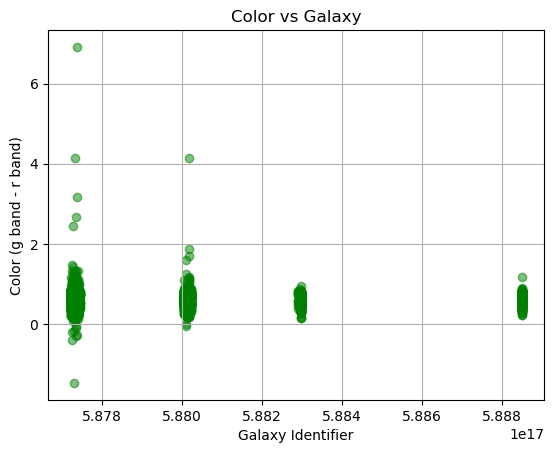

In [49]:
# import our graphing package
import matplotlib.pyplot as plt
plt.scatter(obj, g_r, color='green', alpha=0.5)
plt.title('Color vs Galaxy')
plt.xlabel('Galaxy Identifier')
plt.ylabel('Color (g band - r band)')
plt.grid()

The mean color of spiral galaxies is 0.58
The mean color of elliptical galaxies is 0.75

The standard deviation of the color of spiral galaxies is 0.13
The standard deviation of the color of elliptical galaxies is 0.08


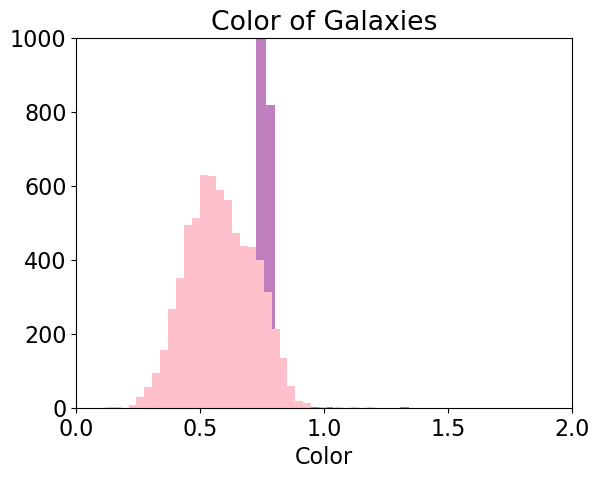

In [59]:
#the below is optional but makes the font a size I can read more easily
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':16}) 


# separate color into elliptical and spiral galaxies
ellip_color = g_r[gz_elliptical_bool]
spiral_color = g_r[gz_spiral_bool]

# create one histogram with elliptical and spiral galaxies on it
plt.hist(ellip_color, bins=100, color='purple', alpha=0.5)
plt.title('Color of Galaxies')
plt.xlabel('Color')

plt.hist(spiral_color, bins=50, color='pink')
plt.ylim(0,1000)
plt.xlim(0,2)

# statistics
import numpy as np 

#fill in the appropriate numpy function and code where the $ is below
print('The mean color of spiral galaxies is', round(np.mean(spiral_color), 2))
print('The mean color of elliptical galaxies is', round(np.mean(ellip_color), 2))
print('')
print('The standard deviation of the color of spiral galaxies is', round(np.std(spiral_color), 2))
print('The standard deviation of the color of elliptical galaxies is', round(np.std(ellip_color), 2))

**What are your results?**

**Answer:** I was proven wrong. 

**What conclusion can you make from your results?**

**Answer:** Elliptical galaxies are older than spiral.

**Is this consistent with waht you learned about galaxy mergers and evolution?**

**Answer:** No, it is not. Because I thought the elliptical was made from the spiral galaxies so I thought it was made after the spiral galaxies.

## Reflection

We are going to move on from galaxies observations and start talking about galaxy simulations. Before we do so, write down some notes in your lab notebook about what you've learned in this unit. Be sure to include some astronomy and some coding. 